In [593]:
EXPERIMENT = "concentric"
SAVE_FIGURES = False

# Imports

In [594]:
import jax
import jax.numpy as np
import equinox as eqx

jax.config.update("jax_enable_x64", True)

import jax_morph as jxm  # type: ignore

key = jax.random.PRNGKey(0)

import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 22})

from tqdm import tqdm

import os

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".95"

In [595]:
if SAVE_FIGURES:
    # create the figures subdirectory if it doesn't exist
    os.makedirs("figures", exist_ok=True)

# Adhesion-Only Forward Model

This section keeps the Fig. 4 notebook workflow, but replaces the trained gene-network model with a two-cell-type adhesion-only forward model. It does not use `train.py`.


In [596]:
from pathlib import Path
import importlib

NOTEBOOK_DIR = Path.cwd()

import istate_and_model
import forward_visualization_helpers as forward_viz

importlib.reload(istate_and_model)
importlib.reload(forward_viz)

from IPython.display import Image as DisplayImage, display
import random

In [597]:
FORWARD_OUTDIR = NOTEBOOK_DIR / "adhesion_forward_outputs"
FORWARD_OUTDIR.mkdir(exist_ok=True)

# J = np.array([3.8, 2.0, 1.5]) # radial
# J = np.array([2.0, 3.8, 1.4]) # intermixed
# J = np.array([3.8, 1.5, 3.0]) # cluster
# J = np.array([0.95, 3.8, 1.1]) # stripes?
# J = np.array([2.5551483141281706, 2.265535426798797, 1.8108800391048878])
J = np.array([3.72457119993578, 1.3533644939185807, 0.9761313307883981])
N_TYPE_1 = 22
N_TYPE_2 = 38

#pg 10 supplement 50 simulation time steps with 200 Brownian relaxation steps per time step
N_STEPS = 1000 #50

#pg 10 supplement core-shell loss radii are 1/2/3 
TARGET_R1 = 1.0
TARGET_R2 = 2.0
SEED = random.randint(0, 1000000)
# SEED = 0

key = jax.random.PRNGKey(SEED)
key, init_key, sim_key = jax.random.split(key, 3)

istate_adhesion = istate_and_model.build_istate(
    init_key,
    n_type_1=N_TYPE_1,
    n_type_2=N_TYPE_2,
)
model_adhesion = istate_and_model.build_model(J)
trajectory_adhesion = istate_and_model.simulate_forward(
    model_adhesion, istate_adhesion, sim_key, n_steps=N_STEPS, history=True
)
fstate_adhesion = jax.tree_util.tree_map(lambda x: x[-1], trajectory_adhesion)

loss = float(istate_and_model.core_shell_loss(fstate_adhesion, TARGET_R1, TARGET_R2))
initial_loss = float(istate_and_model.core_shell_loss(istate_adhesion, TARGET_R1, TARGET_R2))
print(f"Initial loss: {initial_loss:.3f}")
print(f"Final loss: {loss:.3f}")

Initial loss: 0.404
Final loss: 0.082


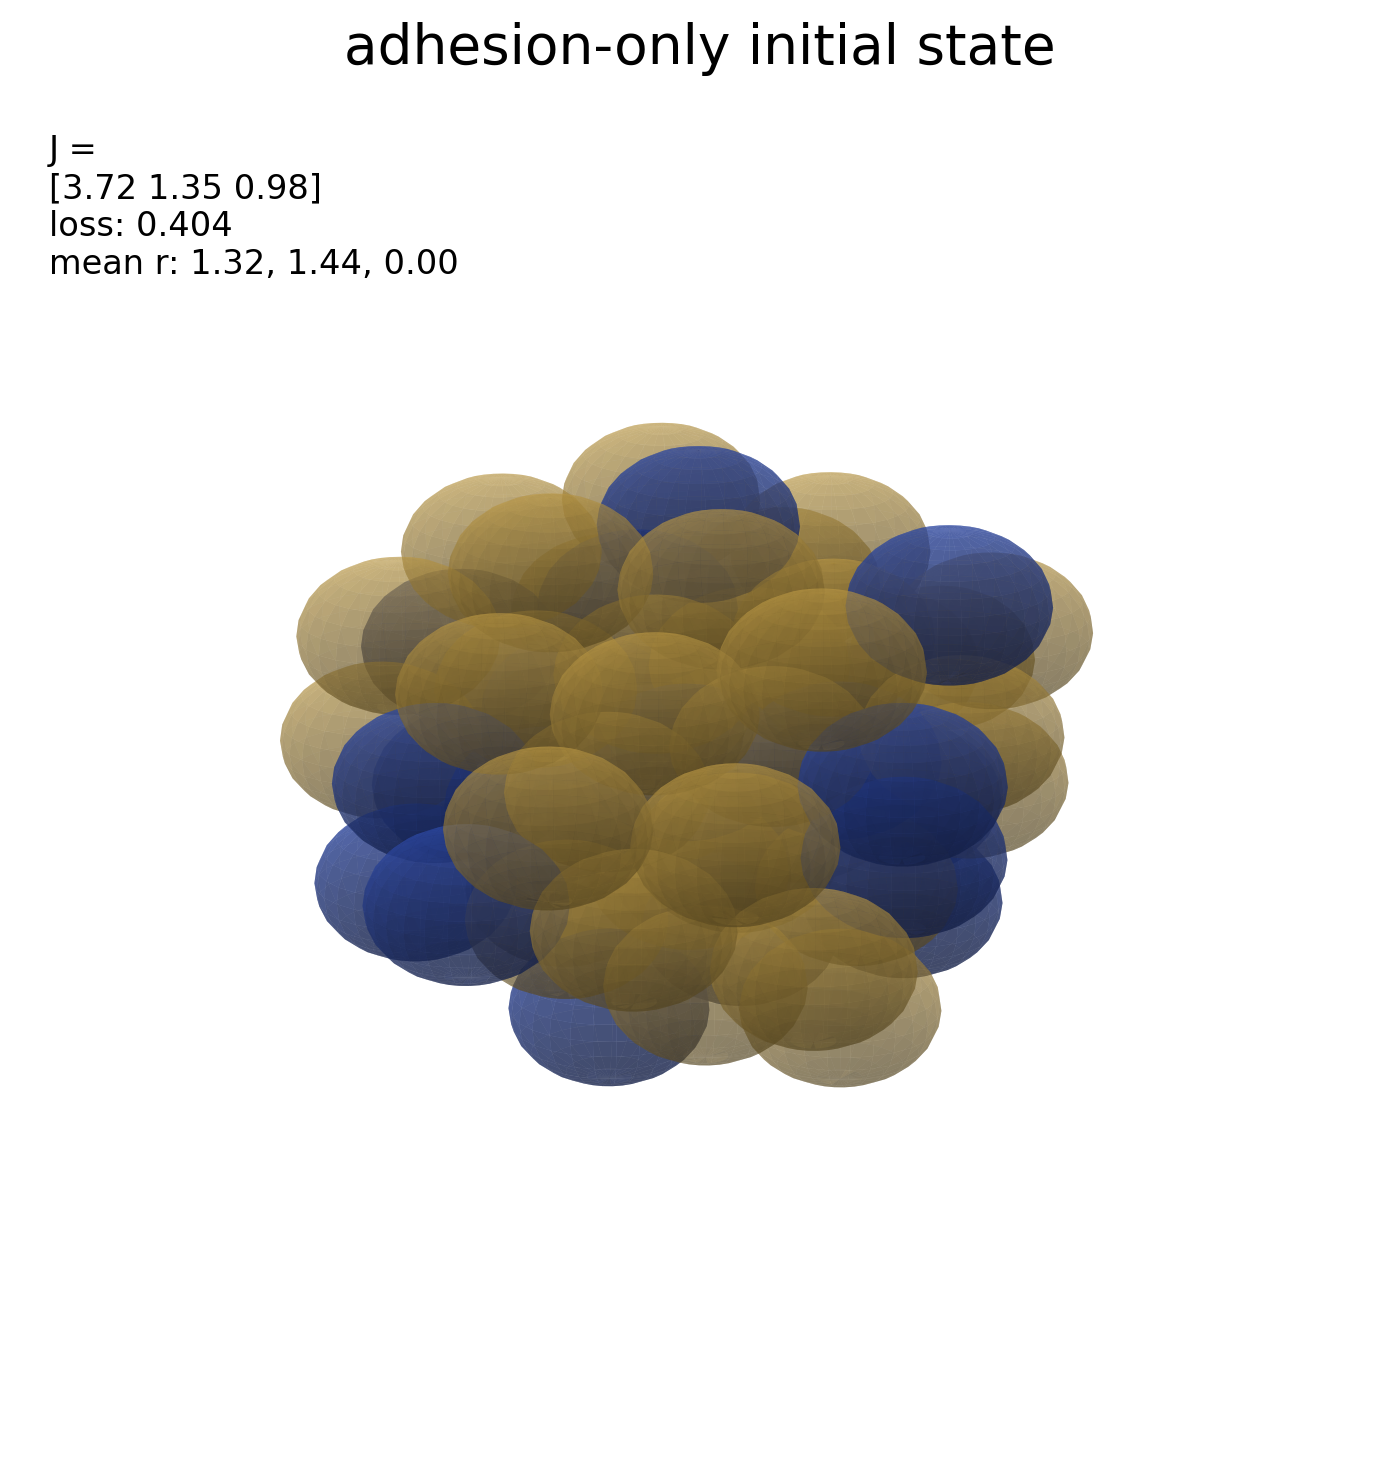

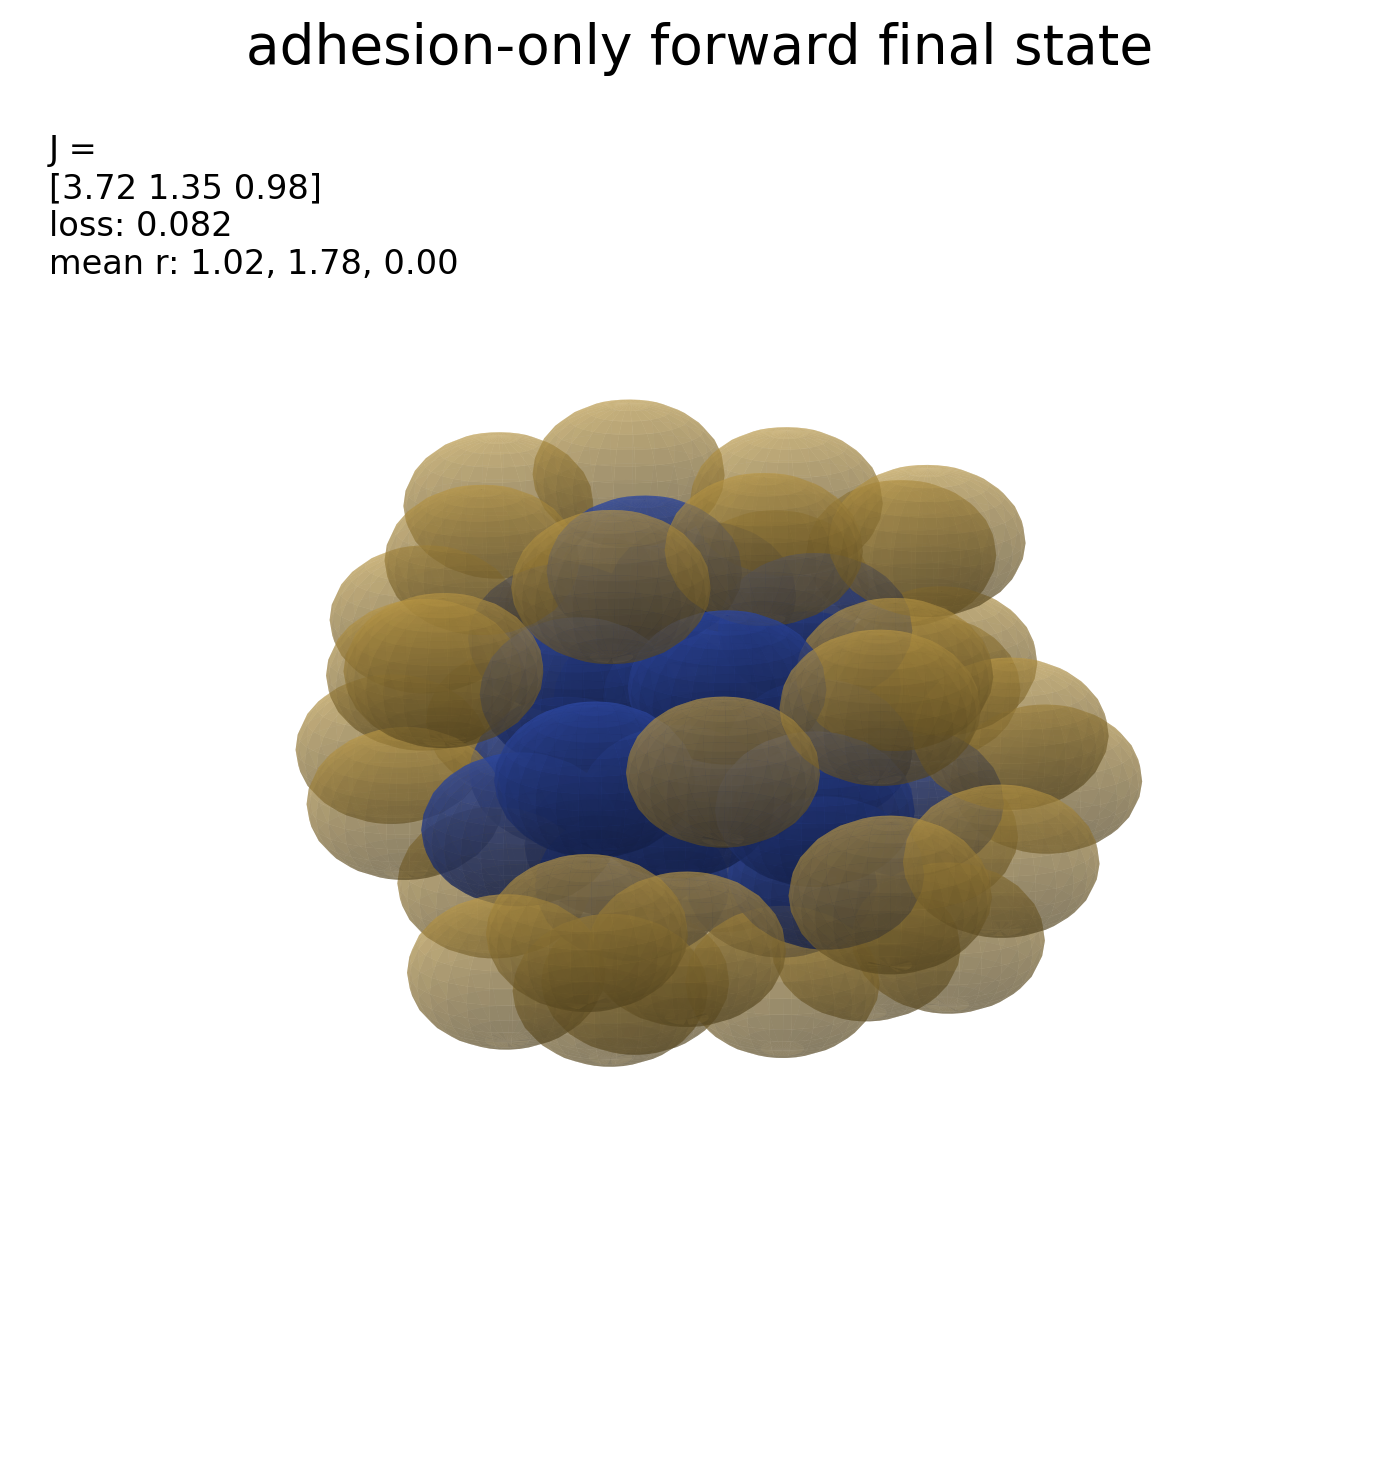

In [598]:
target_radii = np.array([TARGET_R1, TARGET_R2])

preview_outputs = forward_viz.save_initial_final_visualizations(
    notebook_dir=NOTEBOOK_DIR,
    outdir=FORWARD_OUTDIR,
    istate=istate_adhesion,
    fstate=fstate_adhesion,
    target_j=J,
    target_radii=target_radii,
    loss_fn=istate_and_model.core_shell_loss,
)

initial_metrics = preview_outputs["initial_metrics"]
final_metrics = preview_outputs["final_metrics"]

display(DisplayImage(filename=preview_outputs["initial_path"], width=420))
display(DisplayImage(filename=preview_outputs["final_path"], width=420))


In [599]:
# animation_outputs = forward_viz.save_forward_animation(
#     outdir=FORWARD_OUTDIR,
#     istate=istate_adhesion,
#     trajectory=trajectory_adhesion,
# )

# summary = forward_viz.save_forward_summary(
#     outdir=FORWARD_OUTDIR,
#     target_j=J,
#     target_radii=target_radii,
#     n_type_1=N_TYPE_1,
#     n_type_2=N_TYPE_2,
#     n_steps=N_STEPS,
#     seed=SEED,
#     initial_metrics=initial_metrics,
#     final_metrics=final_metrics,
#     animation_html=animation_outputs["animation_html"],
# )

# animation_outputs["animation"]


## Morse Potential Trace During Forward Simulation

This diagnostic reruns the same adhesion-only forward model, but records the Morse energy after every Brownian mechanical relaxation update. With `N_STEPS = 50` and `RELAXATION_STEPS = 200`, the trace has `50 * 200 = 10000` energy samples.

The normal forward simulation only stores the 50 outer states, so this diagnostic explicitly records the inner relaxation steps.


In [600]:
import jax_md
from jax_morph.utils import discount_tangent


def morse_energy_trace_over_relaxation(model, istate, key, *, n_steps=50, relaxation_steps=200):
    relaxation_model = istate_and_model.build_relaxation_model_from_raw_j(model.raw_j)
    relaxer = relaxation_model.substeps[0]
    mech_potential = relaxer.mechanical_potential

    # In this simplified adhesion-only model, cell types/radii/J do not change
    # during the rollout, so the Morse energy function can be reused while
    # positions update inside the Brownian integrator.
    energy_fn = mech_potential.energy_fn(istate)
    init, apply = jax_md.simulate.brownian(
        energy_fn,
        istate.shift,
        dt=relaxer.dt,
        kT=relaxer.kT,
        gamma=relaxer.gamma,
    )

    outer_keys = jax.random.split(key, n_steps)

    def one_outer_step(position, outer_key):
        opt_state = init(outer_key, position)

        def one_relaxation_step(opt_state, _):
            opt_state = apply(opt_state)
            opt_state = eqx.tree_at(
                lambda s: s.position,
                opt_state,
                replace_fn=lambda p: discount_tangent(p, relaxer.discount),
            )
            return opt_state, energy_fn(opt_state.position)

        opt_state, energies = jax.lax.scan(
            one_relaxation_step,
            opt_state,
            xs=None,
            length=relaxation_steps,
        )
        return opt_state.position, energies

    final_position, energy_blocks = jax.lax.scan(
        one_outer_step,
        istate.position,
        outer_keys,
    )
    final_state = eqx.tree_at(lambda s: s.position, istate, final_position)
    energy = energy_blocks.reshape(-1)

    return {
        "energy": energy,
        "outer_step": np.repeat(np.arange(n_steps), relaxation_steps),
        "relaxation_step": np.tile(np.arange(relaxation_steps), n_steps),
        "final_state": final_state,
    }


RELAXATION_STEPS = 100
energy_trace = morse_energy_trace_over_relaxation(
    model_adhesion,
    istate_adhesion,
    sim_key,
    n_steps=N_STEPS,
    relaxation_steps=RELAXATION_STEPS,
)

print("energy samples:", energy_trace["energy"].shape[0])
print("expected:", N_STEPS * RELAXATION_STEPS)
print("initial recorded energy:", float(energy_trace["energy"][0]))
print("final recorded energy:", float(energy_trace["energy"][-1]))


energy samples: 100000
expected: 100000
initial recorded energy: -565.1746325704664
final recorded energy: -686.0845779991675


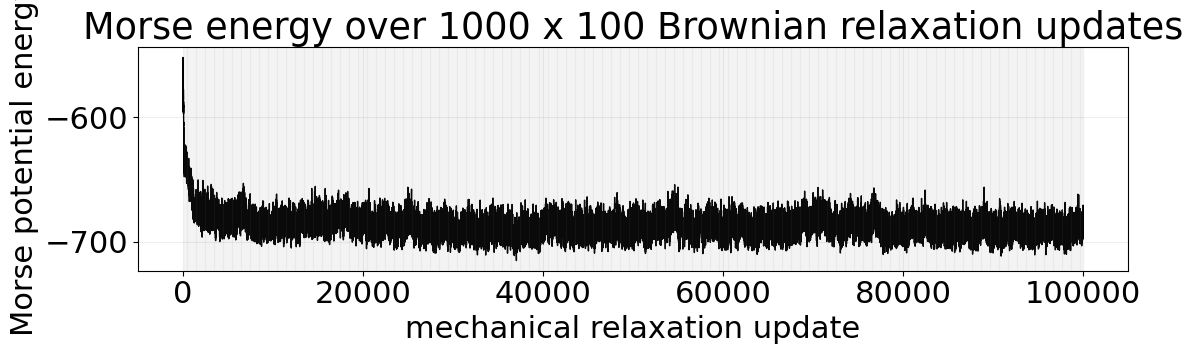

In [601]:
energy = energy_trace["energy"]
outer_energy = energy.reshape(N_STEPS, RELAXATION_STEPS)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.arange(energy.shape[0]), energy, color="black", linewidth=1.0)
for boundary in range(RELAXATION_STEPS, energy.shape[0], RELAXATION_STEPS):
    ax.axvline(boundary, color="gray", alpha=0.08, linewidth=0.8)
ax.set_xlabel("mechanical relaxation update")
ax.set_ylabel("Morse potential energy")
ax.set_title(f"Morse energy over {N_STEPS} x {RELAXATION_STEPS} Brownian relaxation updates")
ax.grid(alpha=0.2)
fig.tight_layout()


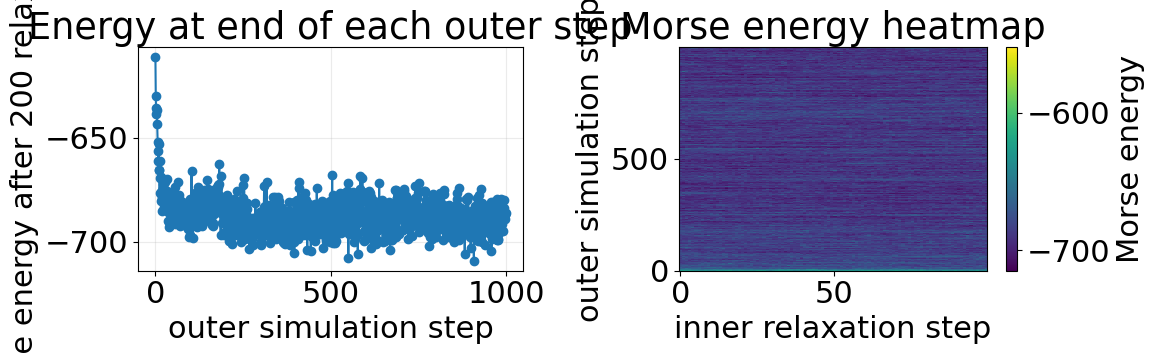

In [602]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.arange(N_STEPS), outer_energy[:, -1], marker="o", linewidth=1.5)
axes[0].set_xlabel("outer simulation step")
axes[0].set_ylabel("Morse energy after 200 relaxations")
axes[0].set_title("Energy at end of each outer step")
axes[0].grid(alpha=0.25)

im = axes[1].imshow(
    outer_energy,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
)
axes[1].set_xlabel("inner relaxation step")
axes[1].set_ylabel("outer simulation step")
axes[1].set_title("Morse energy heatmap")
fig.colorbar(im, ax=axes[1], label="Morse energy")

fig.tight_layout()


# Load Results

In [603]:
def _count_eqx_arrays(path):
    """Count NumPy arrays in an Equinox leaf stream without deserializing a PyTree."""
    import numpy as onp

    count = 0
    with open(path, "rb") as fh:
        while True:
            try:
                onp.load(fh, allow_pickle=False)
                count += 1
            except EOFError:
                break
    return count


def load_run_data_fig4(run_id):
    """Load training log, initial state, and trained model for a given run."""

    key = jax.random.PRNGKey(0)

    import json

    with open(f"trained_models/train-{EXPERIMENT}-opt-hyperparams.json", "r") as f:
        opt_hyper = json.load(f)

    root_dir = f"trained_models/train-{EXPERIMENT}-{run_id}"
    results_path = f"{root_dir}/results-{EXPERIMENT}-{run_id}.eqx"

    from collections import namedtuple

    OptResults = namedtuple("OptimizationResults", ["model", "loss", "loss_aux", "grad"])

    # Equinox needs the template list length to exactly match the saved file.
    # With validation there are two logged lists; without validation there is only loss.
    n_arrays = _count_eqx_arrays(results_path)
    has_val_loss = opt_hyper.get("N_VAL_EPISODES", 0) > 0
    n_log_entries = n_arrays // 2 if has_val_loss else n_arrays
    opt_results_like = OptResults(
        None,
        [0.0] * n_log_entries,
        [0.0] * n_log_entries if has_val_loss else None,
        None,
    )

    with open(results_path, "rb") as fh:
        opt_results = eqx.tree_deserialise_leaves(fh, like=opt_results_like)

    TrainingLog = namedtuple("TrainingLog", ["loss", "val_loss"])
    training_log = TrainingLog(opt_results.loss, opt_results.loss_aux)

    n_cells = opt_hyper.get("N_CELLS")
    if n_cells is None:
        n_type_1 = opt_hyper.get("N_TYPE_1", 10)
        n_type_2 = opt_hyper.get("N_TYPE_2", 30)
        n_cells = n_type_1 + n_type_2
        initial_type_1_fraction = n_type_1 / n_cells
    else:
        initial_type_1_fraction = opt_hyper.get("INITIAL_TYPE_1_FRACTION", 0.5)
        n_type_1 = int(np.clip(round(n_cells * initial_type_1_fraction), 1, n_cells - 1))
        n_type_2 = n_cells - n_type_1

    istate = istate_and_model.build_istate(key, n_type_1=n_type_1, n_type_2=n_type_2)

    class LegacyTrainableJModel(jxm.SimulationStep):
        raw_j: jax.Array

        def return_logprob(self) -> bool:
            return False

        def __call__(self, state, *, key=None, **kwargs):
            return istate_and_model.build_relaxation_model_from_raw_j(self.raw_j)(state, key=key)

    init_model_path = f"{root_dir}/init-{EXPERIMENT}-{run_id}.eqx"
    trained_model_path = f"{root_dir}/trained-{EXPERIMENT}-{run_id}.eqx"
    n_model_arrays = _count_eqx_arrays(init_model_path)

    if n_model_arrays == 1:
        model_template = LegacyTrainableJModel(istate_and_model.raw_j_from_visible_j(np.array([2.0, 2.0, 2.0])))
        print("Detected legacy one-array model checkpoint without raw_fraction.")
    else:
        model_template = istate_and_model.build_model(
            np.array([2.0, 2.0, 2.0]),
            initial_type_1_fraction=initial_type_1_fraction,
        )

    with open(init_model_path, "rb") as fh:
        initial_model = eqx.tree_deserialise_leaves(fh, like=model_template)

    with open(trained_model_path, "rb") as fh:
        trained_model = eqx.tree_deserialise_leaves(fh, like=model_template)

    print(f"Loaded {n_log_entries} logged epochs from {results_path}")
    print(f"Initial composition from hyperparams: n_type_1={n_type_1}, n_type_2={n_type_2}, frac={initial_type_1_fraction:.3f}")
    return opt_hyper, training_log, istate, initial_model, trained_model


# Single Run

In [604]:
RUN_ID = 0


In [605]:
opt_hyper, training_log, istate, initial_model, trained_model = load_run_data_fig4(
    RUN_ID
)

Detected legacy one-array model checkpoint without raw_fraction.
Loaded 1001 logged epochs from trained_models/train-concentric-0/results-concentric-0.eqx
Initial composition from hyperparams: n_type_1=20, n_type_2=40, frac=0.333


## Loss Curves


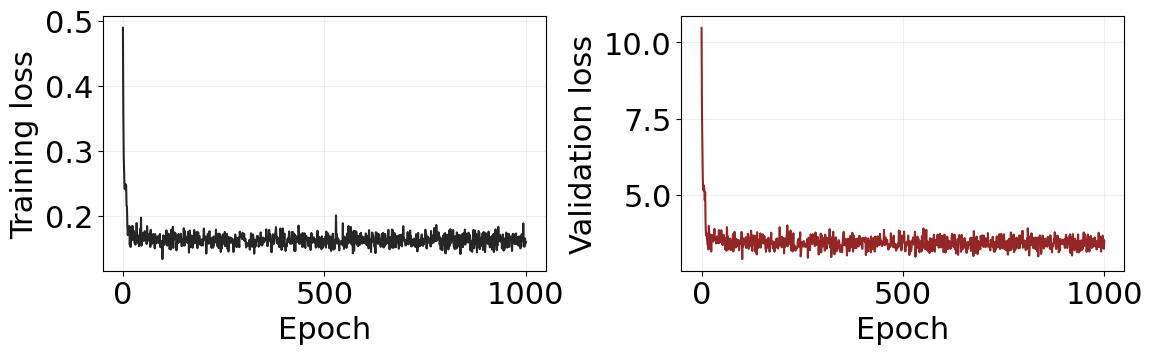

In [606]:
epochs = np.arange(len(training_log.loss))

if training_log.val_loss is None:
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.plot(epochs, training_log.loss, color="black", alpha=0.85)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training loss")
    ax.grid(alpha=0.2)
else:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(epochs, training_log.loss, color="black", alpha=0.85)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Training loss")
    ax[0].grid(alpha=0.2)

    ax[1].plot(epochs, training_log.val_loss, color="maroon", alpha=0.85)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Validation loss")
    ax[1].grid(alpha=0.2)

fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(f"figures/loss_curves_{EXPERIMENT}-{RUN_ID}.svg", dpi=300)


## Forward Comparison


In [607]:
def _simulate_final_state(model, istate, key, n_sim_steps):
    result = jxm.simulate(model, istate, key, n_sim_steps)
    return result[0] if isinstance(result, tuple) else result


TRAINED_OUTDIR = NOTEBOOK_DIR / "trained_forward_outputs"
TRAINED_OUTDIR.mkdir(exist_ok=True)

N_SIM_STEPS = opt_hyper.get("N_STEPS", 50)
TARGET_R1 = opt_hyper.get("TARGET_R1", 1.0)
TARGET_R2 = opt_hyper.get("TARGET_R2", 2.0)
target_radii = np.array([TARGET_R1, TARGET_R2])

initial_j = istate_and_model.visible_j_from_raw_j(initial_model.raw_j)
trained_j = istate_and_model.visible_j_from_raw_j(trained_model.raw_j)

sim_key = jax.random.PRNGKey(random.randint(0, 10000)) #1000 + int(RUN_ID)
fstate_initial_model = _simulate_final_state(initial_model, istate, sim_key, N_SIM_STEPS)
fstate_trained_model = _simulate_final_state(trained_model, istate, sim_key, N_SIM_STEPS)

initial_state_loss = float(istate_and_model.core_shell_loss(istate, TARGET_R1, TARGET_R2))
initial_model_loss = float(istate_and_model.core_shell_loss(fstate_initial_model, TARGET_R1, TARGET_R2))
trained_model_loss = float(istate_and_model.core_shell_loss(fstate_trained_model, TARGET_R1, TARGET_R2))

print("Initial J:", np.asarray(initial_j))
print("Trained J:", np.asarray(trained_j))
print(f"Initial state loss: {initial_state_loss:.3f}")
print(f"Final loss with initial J: {initial_model_loss:.3f}")
print(f"Final loss with trained J: {trained_model_loss:.3f}")


Initial J: [1.08002565 1.91885708 2.93872359]
Trained J: [3.79946049 1.37314491 0.81940706]
Initial state loss: 0.465
Final loss with initial J: 0.630
Final loss with trained J: 0.105


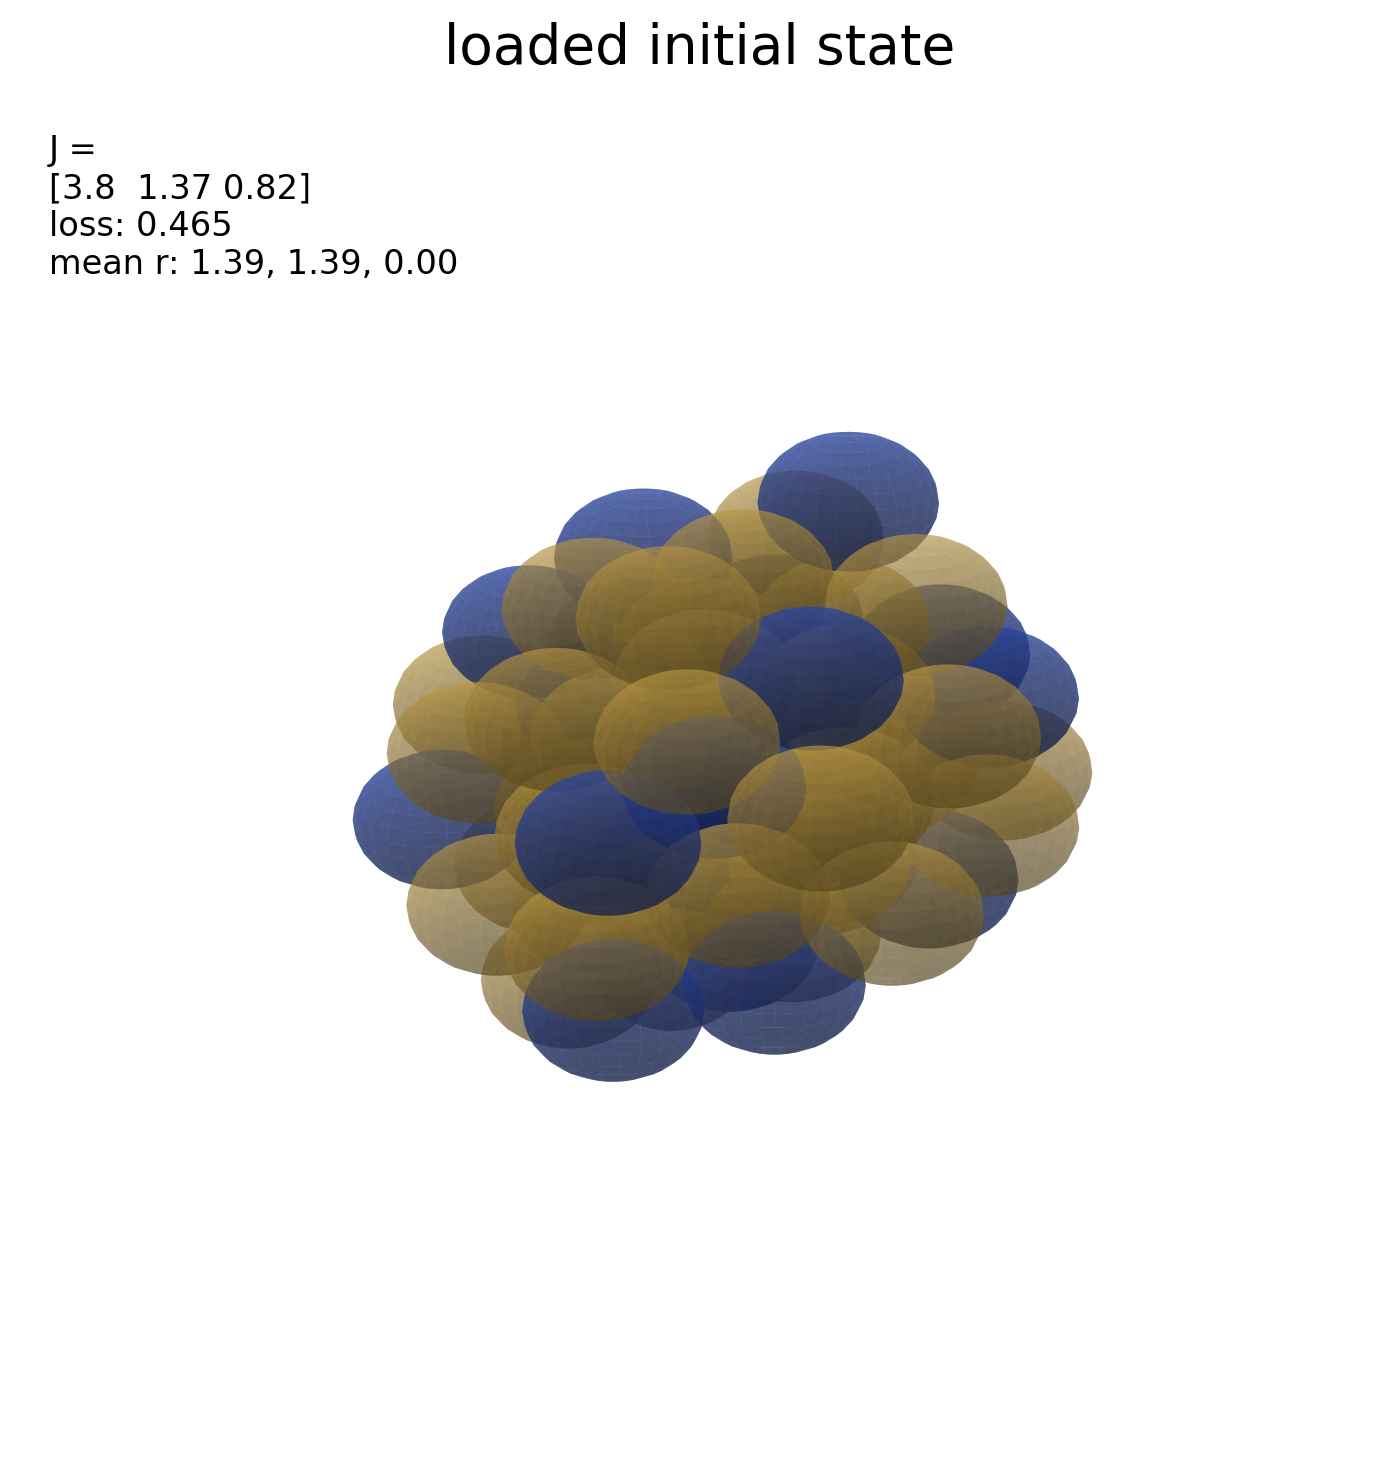

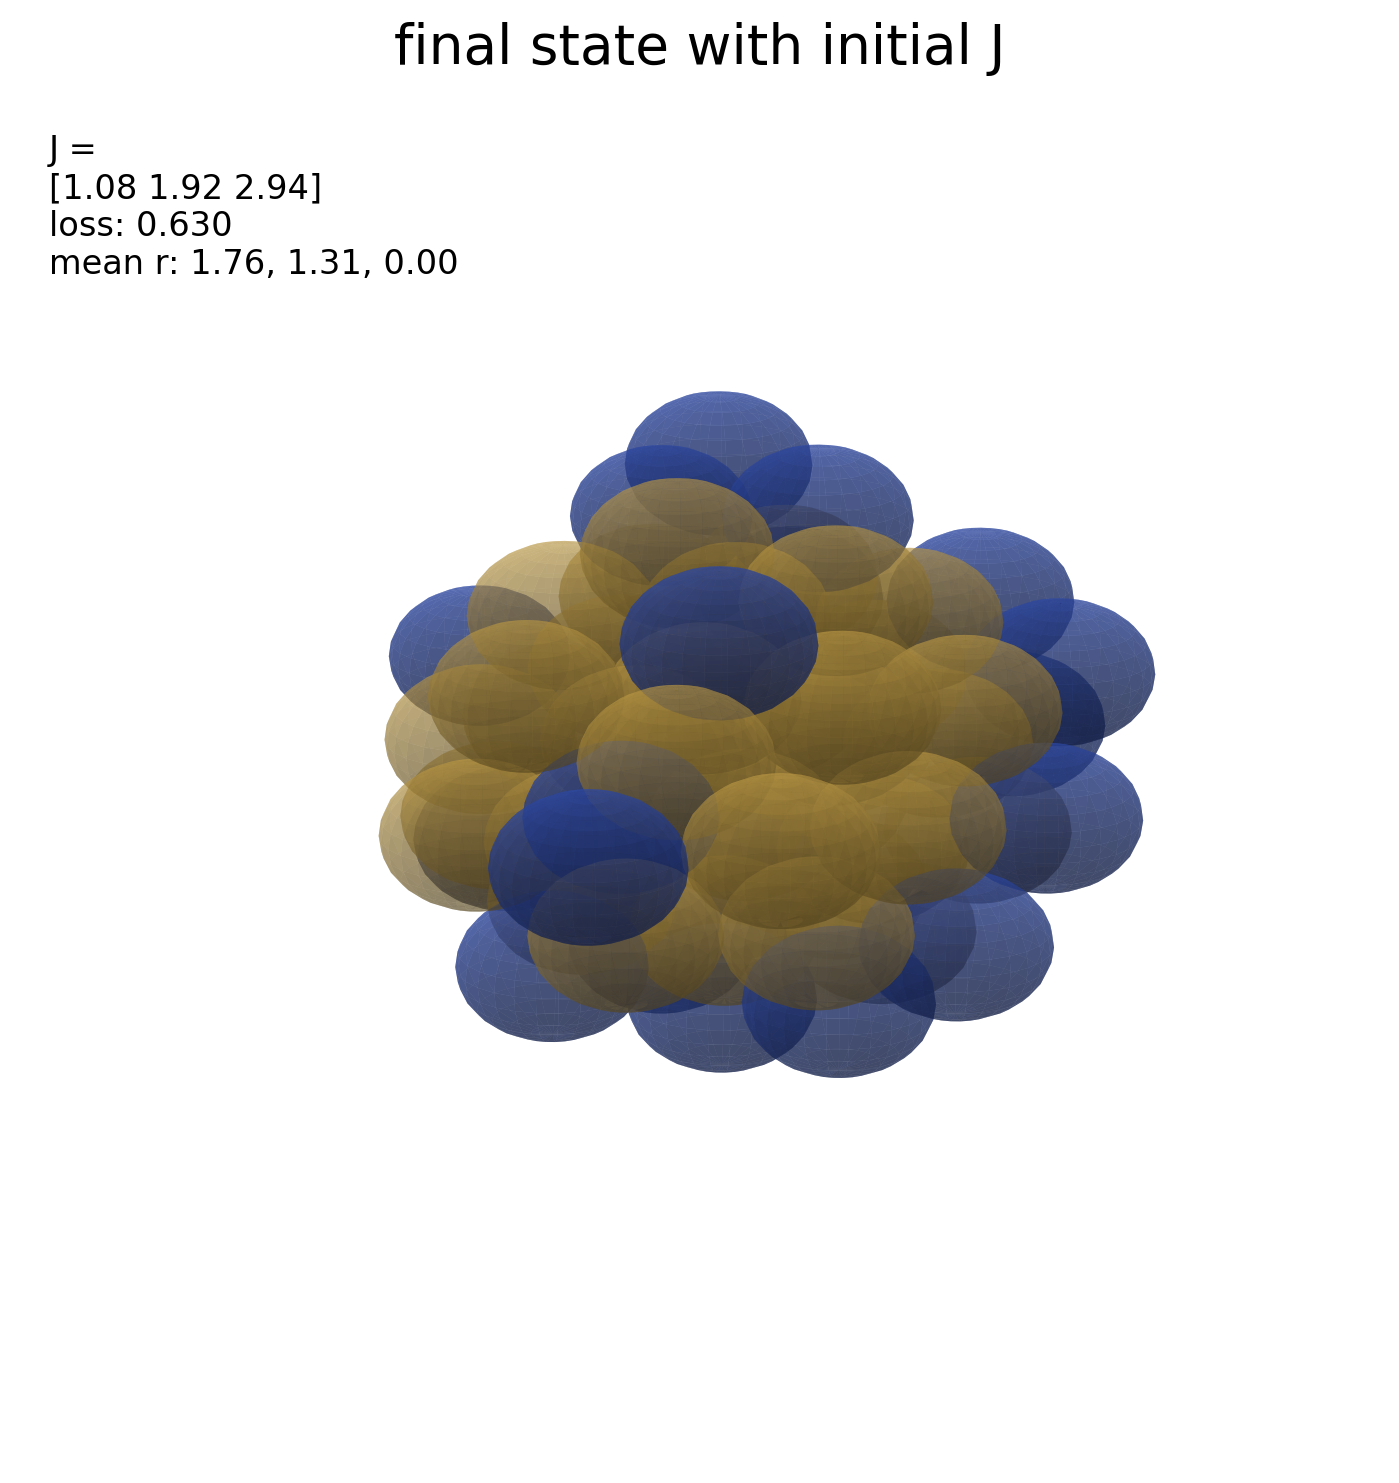

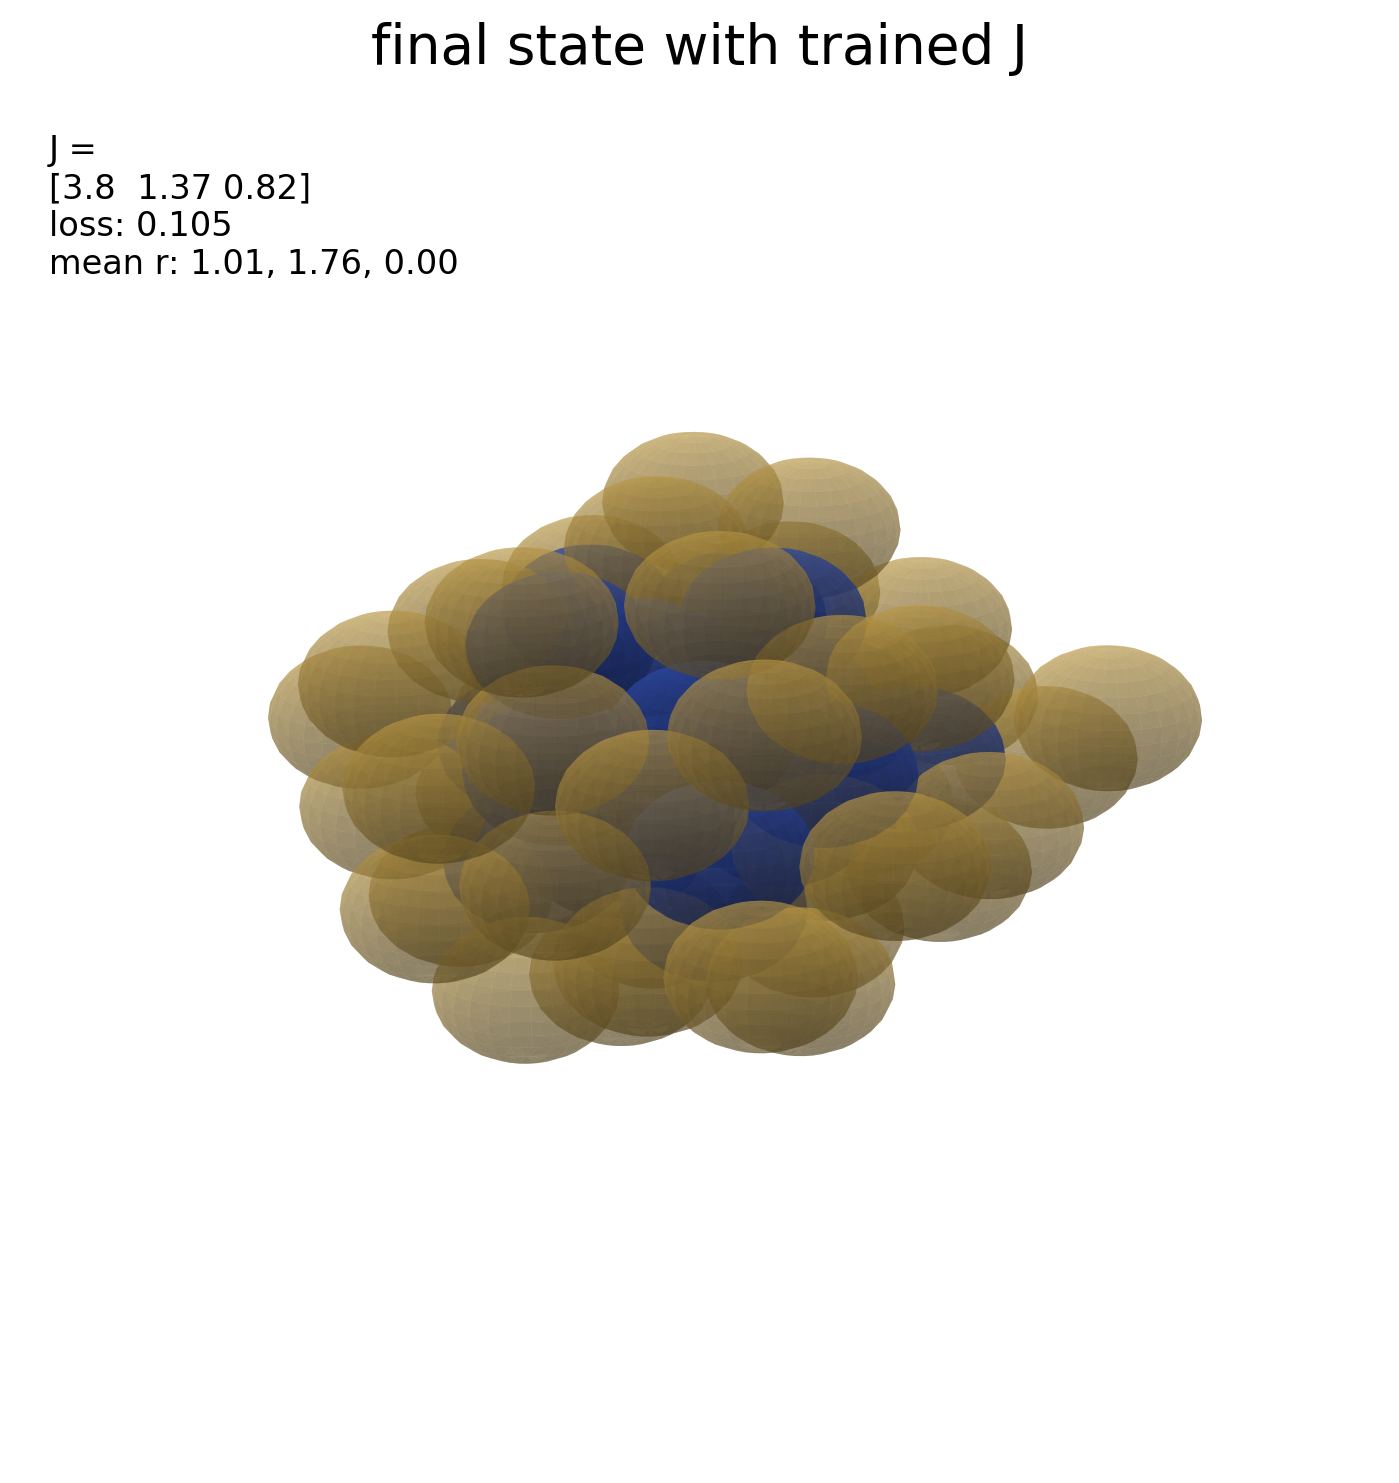

In [608]:
initial_preview = forward_viz.save_state_visualization(
    notebook_dir=NOTEBOOK_DIR,
    outdir=TRAINED_OUTDIR,
    state=istate,
    title="loaded initial state",
    filename=f"{EXPERIMENT}-{RUN_ID}-initial-state.png",
    target_j=trained_j,
    target_radii=target_radii,
    loss_fn=istate_and_model.core_shell_loss,
)

untrained_preview = forward_viz.save_state_visualization(
    notebook_dir=NOTEBOOK_DIR,
    outdir=TRAINED_OUTDIR,
    state=fstate_initial_model,
    title="final state with initial J",
    filename=f"{EXPERIMENT}-{RUN_ID}-final-initial-j.png",
    target_j=initial_j,
    target_radii=target_radii,
    loss_fn=istate_and_model.core_shell_loss,
)

trained_preview = forward_viz.save_state_visualization(
    notebook_dir=NOTEBOOK_DIR,
    outdir=TRAINED_OUTDIR,
    state=fstate_trained_model,
    title="final state with trained J",
    filename=f"{EXPERIMENT}-{RUN_ID}-final-trained-j.png",
    target_j=trained_j,
    target_radii=target_radii,
    loss_fn=istate_and_model.core_shell_loss,
)

display(DisplayImage(filename=initial_preview["path"], width=360))
display(DisplayImage(filename=untrained_preview["path"], width=360))
display(DisplayImage(filename=trained_preview["path"], width=360))
